In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from datetime import timedelta
from netCDF4 import Dataset, date2num, num2date
import cftime
import glob
import os
import csv
%matplotlib inline
import datetime
import matplotlib.dates as mdates
import matplotlib.dates as md
import metpy.calc as mpcalc
from metpy.units import units
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator

files_s10 = sorted(glob.glob('/Users/dave121504/ARM Project/BNF_files/s10/bnfstampS10*.nc'))
s10 = xr.open_mfdataset(files_s10, combine='by_coords')

files_s13 = sorted(glob.glob('/Users/dave121504/ARM Project/BNF_files/s13/bnfstampS13*.nc'))
s13 = xr.open_mfdataset(files_s13, combine='by_coords')

files_s14 = sorted(glob.glob('/Users/dave121504/ARM Project/BNF_files/s14/bnfstampS14*.nc'))
s14 = xr.open_mfdataset(files_s14, combine='by_coords')

files_s20 = sorted(glob.glob('/Users/dave121504/ARM Project/BNF_files/s20/bnfstampS20*.nc'))
s20 = xr.open_mfdataset(files_s20, combine='by_coords')

files_s30 = sorted(glob.glob('/Users/dave121504/ARM Project/BNF_files/s30/bnfstampS30*.nc'))
s30 = xr.open_mfdataset(files_s30, combine='by_coords')

files_s40 = sorted(glob.glob('/Users/dave121504/ARM Project/BNF_files/s40/bnfstampS40*.nc'))
s40 = xr.open_mfdataset(files_s40, combine='by_coords')

files_s10_precip = sorted(glob.glob('/Users/dave121504/ARM Project/BNF_files/s10_precip/bnfstamp*.nc'))
s10_precip = xr.open_mfdataset(files_s10_precip, combine='by_coords')

files_s13_precip = sorted(glob.glob('/Users/dave121504/ARM Project/BNF_files/s13_precip/bnfstamp*.nc'))
s13_precip = xr.open_mfdataset(files_s13_precip, combine='by_coords')

files_s14_precip = sorted(glob.glob('/Users/dave121504/ARM Project/BNF_files/s14_precip/bnfstamp*.nc'))
s14_precip = xr.open_mfdataset(files_s14_precip, combine='by_coords')

files_s20_precip = sorted(glob.glob('/Users/dave121504/ARM Project/BNF_files/s20_precip/bnfstamp*.nc'))
s20_precip = xr.open_mfdataset(files_s20_precip, combine='by_coords')

files_s30_precip = sorted(glob.glob('/Users/dave121504/ARM Project/BNF_files/s30_precip/bnfstamp*.nc'))
s30_precip = xr.open_mfdataset(files_s30_precip, combine='by_coords')

files_s40_precip = sorted(glob.glob('/Users/dave121504/ARM Project/BNF_files/s40_precip/bnfstamp*.nc'))
s40_precip = xr.open_mfdataset(files_s40_precip, combine='by_coords')

In [9]:
s10

<xarray.Dataset> Size: 14MB
Dimensions:                                  (time: 17352, depth: 5)
Coordinates:
  * time                                     (time) datetime64[ns] 139kB 2025...
  * depth                                    (depth) int32 20B 5 10 20 50 100
Data variables: (12/49)
    base_time                                (time) datetime64[ns] 139kB 2025...
    time_offset                              (time) datetime64[ns] 139kB dask.array<chunksize=(48,), meta=np.ndarray>
    soil_specific_water_content_west         (time, depth) float32 347kB dask.array<chunksize=(48, 5), meta=np.ndarray>
    qc_soil_specific_water_content_west      (time, depth) int32 347kB dask.array<chunksize=(48, 5), meta=np.ndarray>
    plant_water_availability_west            (time, depth) float32 347kB dask.array<chunksize=(48, 5), meta=np.ndarray>
    qc_plant_water_availability_west         (time, depth) int32 347kB dask.array<chunksize=(48, 5), meta=np.ndarray>
    ...                                       ...
    qc_real_dielectric_permittivity_east     (time, depth) int32 347kB dask.array<chunksize=(48, 5), meta=np.ndarray>
    battery_voltage                          (time) float32 69kB dask.array<chunksize=(48,), meta=np.ndarray>
    qc_battery_voltage                       (time) int32 69kB dask.array<chunksize=(48,), meta=np.ndarray>
    lat                                      (time) float32 69kB 34.34 ... 34.34
    lon                                      (time) float32 69kB -87.35 ... -...
    alt                                      (time) float32 69kB 284.0 ... 284.0
Attributes: (12/20)
    command_line:          stamp_ingest -s bnf -f S10 --max-runtime 0
    Conventions:           ARM-1.1
    process_version:       ingest-stamp-1.2-1.el9
    dod_version:           stamp-b1-1.0
    input_source:          /data/collection/bnf/bnfstampS10.00/STAMP_Table30....
    site_id:               bnf
    ...                    ...
    qc_bit_1_assessment:   Bad
    qc_bit_2_description:  Value is less than the valid_min.
    qc_bit_2_assessment:   Bad
    qc_bit_3_description:  Value is greater than the valid_max.
    qc_bit_3_assessment:   Bad
    history:               created by user armflowprod on machine prod-slurmn...

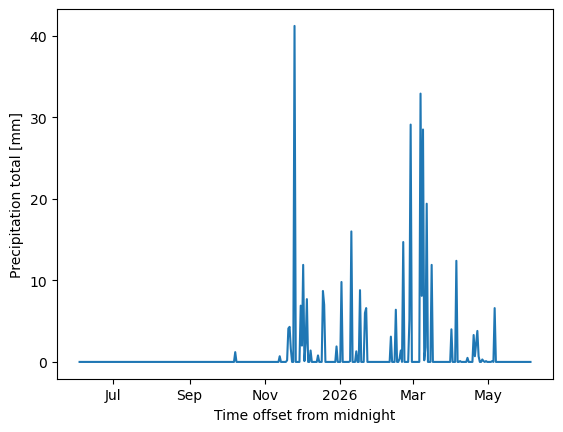

In [13]:
s10_watcont_5cm = s10['loam_soil_water_content_west']
s13_watcont_5cm = s13['loam_soil_water_content_west']
s14_watcont_5cm = s14['loam_soil_water_content_west']
s20_watcont_5cm = s20['loam_soil_water_content_west']
s30_watcont_5cm = s30['loam_soil_water_content_west']
s40_watcont_5cm = s40['loam_soil_water_content_west']

s10_p = s10_precip['precip'].resample(time='1D').sum()
s13_p = s13_precip['precip'].resample(time='1D').sum()
s14_p = s14_precip['precip'].resample(time='1D').sum()
s20_p = s20_precip['precip'].resample(time='1D').sum()
s30_p = s30_precip['precip'].resample(time='1D').sum()
s40_p = s40_precip['precip'].resample(time='1D').sum()

s14_p.plot()

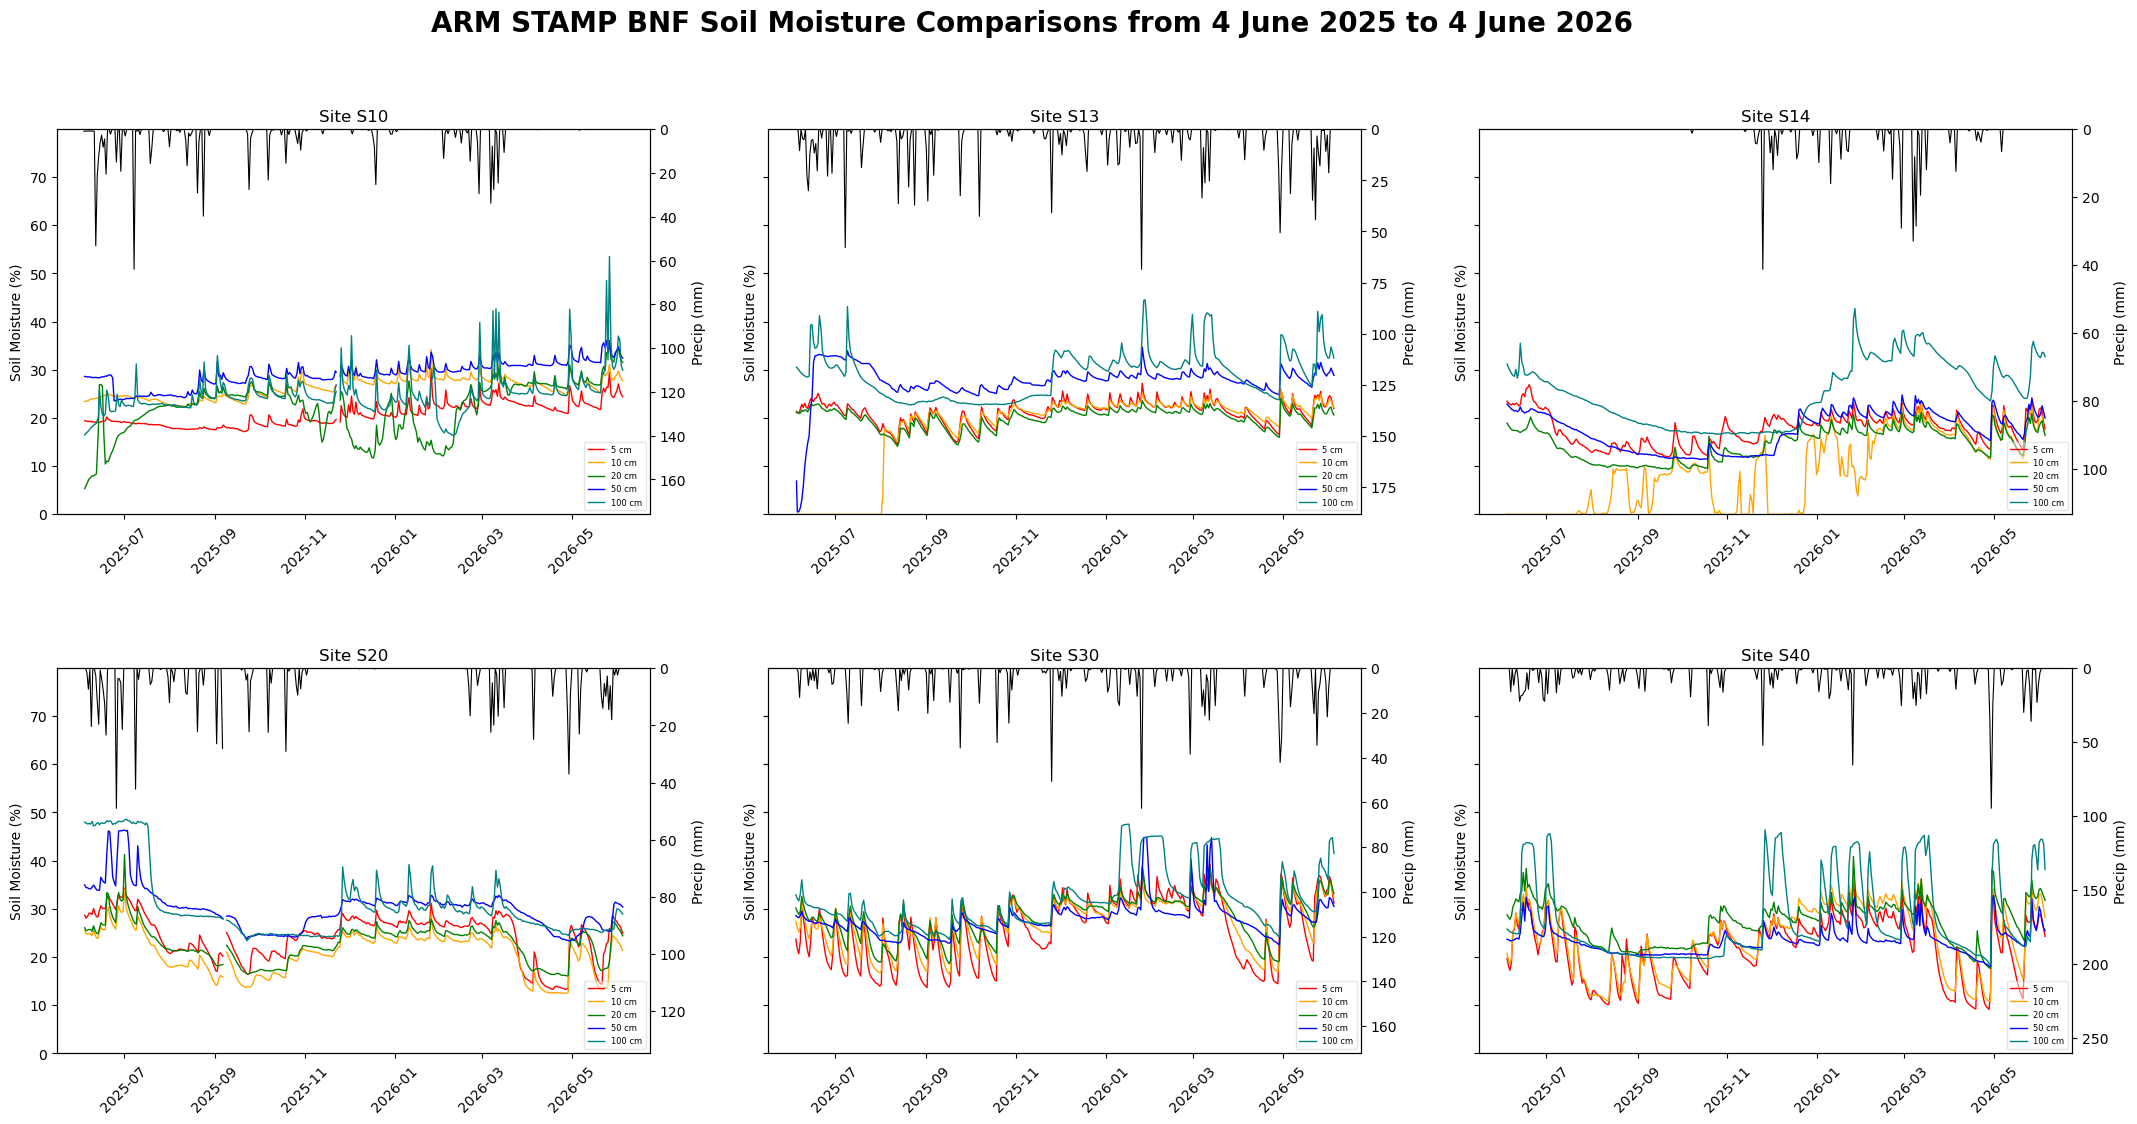

In [11]:
sites = {
    'S10': s10,
    'S13': s13,
    'S14': s14,
    'S20': s20,
    'S30': s30,
    'S40': s40,
    
}

precip_sites = {
    'S10_precip': s10_p,
    'S13_precip': s13_p,
    'S14_precip': s14_p,
    'S20_precip': s20_p,
    'S30_precip': s30_p,
    'S40_precip': s40_p,
}
    

fig, axes = plt.subplots(2, 3, figsize=(26, 12), sharey = True)



#soil moisture
for ax, (name, ds) in zip(axes.flat, sites.items()):
    y1 = ds['loam_soil_water_content_west'].isel(depth=0).resample(time='1D').mean()
    ax.plot(ds['time'].resample(time='1D').mean(), y1, linewidth=1, color = 'red', label = '5 cm')
   
    y2 = ds['loam_soil_water_content_west'].isel(depth=1).resample(time='1D').mean()
    ax.plot(ds['time'].resample(time='1D').mean(), y2, linewidth=1, color = 'orange', label = '10 cm')

    y3 = ds['loam_soil_water_content_west'].isel(depth=2).resample(time='1D').mean()
    ax.plot(ds['time'].resample(time='1D').mean(), y3, linewidth=1, color = 'green', label = '20 cm')

    y4 = ds['loam_soil_water_content_west'].isel(depth=3).resample(time='1D').mean()
    ax.plot(ds['time'].resample(time='1D').mean(), y4, linewidth=1, color = 'blue', label = '50 cm')

    y5 = ds['loam_soil_water_content_west'].isel(depth=4).resample(time='1D').mean()
    ax.plot(ds['time'].resample(time='1D').mean(), y5, linewidth=1, color = 'teal', label = '100 cm')
    ax.set_ylim(0, ds['loam_soil_water_content_west'].max() * 1.7)

   
    
    ax.tick_params(axis = 'x', labelrotation = 45, labelsize = 10)
    ax.set_title(f'Site {name}')
    ax.legend(fontsize = 6, loc = 'lower right', framealpha = 0.5)
    ax.set_ylabel('Soil Moisture (%)', fontsize = 10)

#precip
for ax, (name, ds) in zip(axes.flat, precip_sites.items()):

    p1 = ds
    p_plot = ax.twinx()
    p_plot.set_ylim(p1.max() * 2.75, 0)
    p_plot.plot(ds['time'].resample(time='1D').mean(), p1, linewidth = 0.8, color = 'black', label = 'precip')
    p_plot.set_ylabel('Precip (mm)', fontsize = 10)
    
    
        

plt.subplots_adjust(hspace=0.4, wspace = 0.2)


time = s10_watcont_5cm['time']
start_date = "4 June 2025"
end_date = "4 June 2026"
fig.suptitle(f"ARM STAMP BNF Soil Moisture Comparisons from {start_date} to {end_date}", fontweight = 'bold', fontsize = 20)   
plt.savefig('bnf_soil_moisture', dpi=300, bbox_inches='tight')




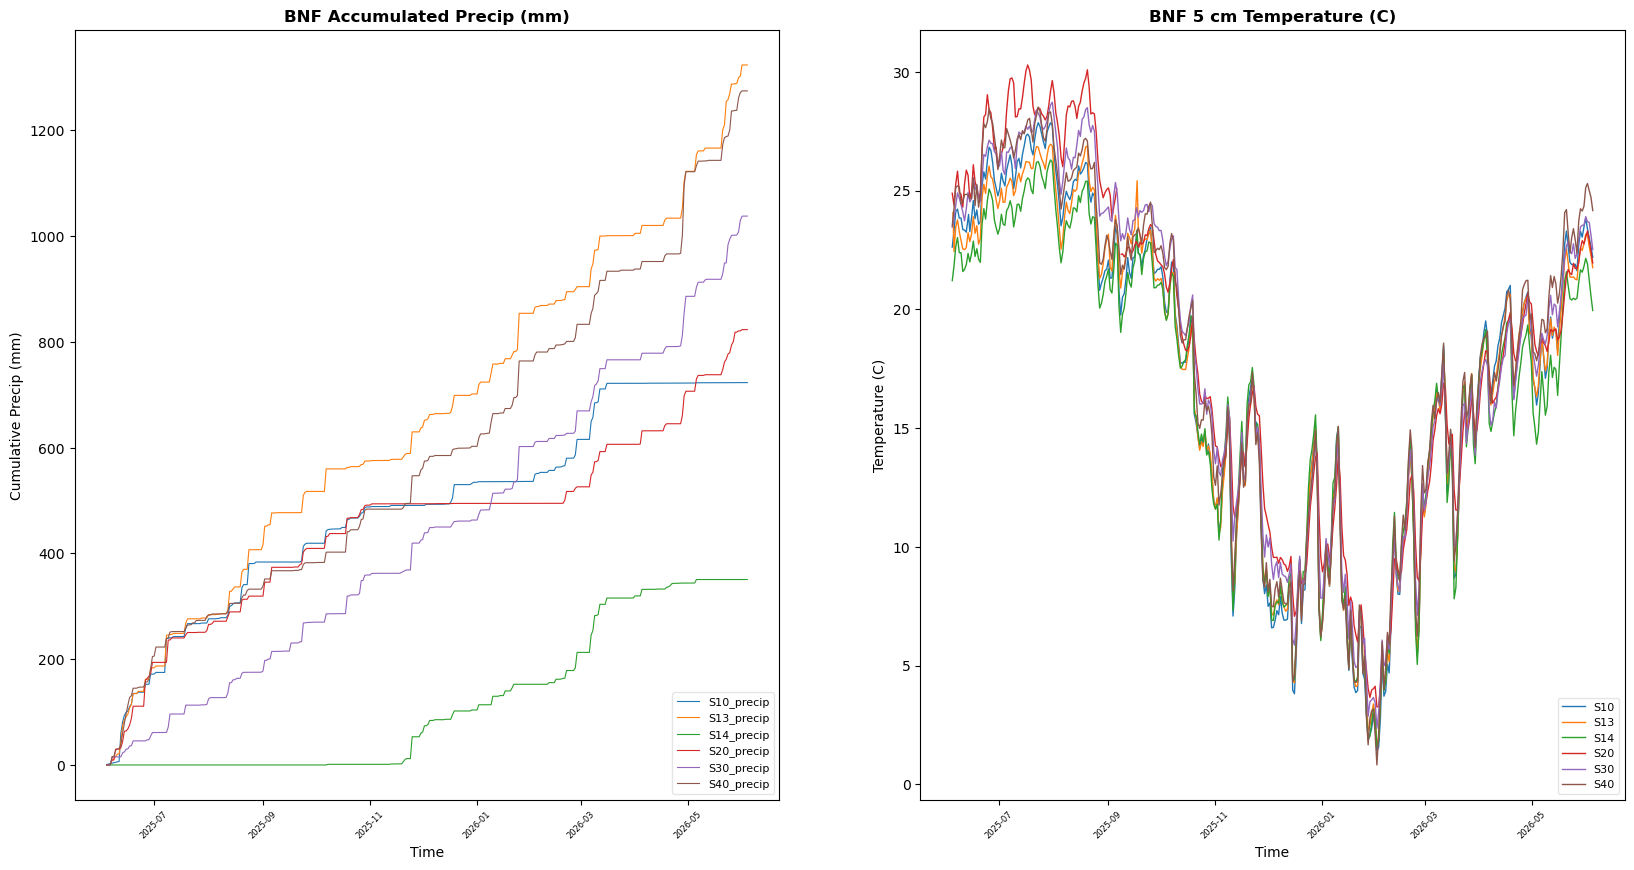

In [12]:
#plot temperature across all sites only at 5 cm

fig, axes = plt.subplots(1, 2, figsize = (20, 10))
for name, ds in precip_sites.items(): 
    p1 = ds
    p1_cum = p1.cumsum(dim='time')
    axes[0].plot(
        p1_cum['time'],
        p1_cum,
        linewidth=0.8,
        label=name
    )

axes[0].set_ylabel('Cumulative Precip (mm)', fontsize=10)
axes[0].set_xlabel('Time', fontsize=10)
axes[0].legend(loc = 'lower right', fontsize = 8, framealpha = 0.5)

for name, ds in sites.items():
    axes[1].plot(ds['time'].resample(time='1D').mean(), ds['soil_temperature_west'].isel(depth=0).resample(time='1D').mean(), linewidth=1, label = name)

axes[1].set_ylabel('Temperature (C)', fontsize=10)
axes[1].set_xlabel('Time', fontsize=10)
axes[1].legend(loc = 'lower right', fontsize = 8, framealpha= 0.5)   

axes[0].tick_params(axis = 'x', labelrotation = 45, labelsize = 6)
axes[1].tick_params(axis = 'x', labelrotation = 45, labelsize = 6)

axes[0].set_title('BNF Accumulated Precip (mm)', fontsize = 12, fontweight = 'bold')
axes[1].set_title('BNF 5 cm Temperature (C)', fontsize = 12, fontweight = 'bold')

plt.savefig('bnf_precip_temperature', dpi=300, bbox_inches='tight')
